/tmp/ipykernel_59251/2910486110.py:116: RuntimeWarning: overflow encountered in exp
  B_nu = (2 * H_CGS * nu_rest**3 / C_CGS**2) / (np.exp(exp_val) - 1)


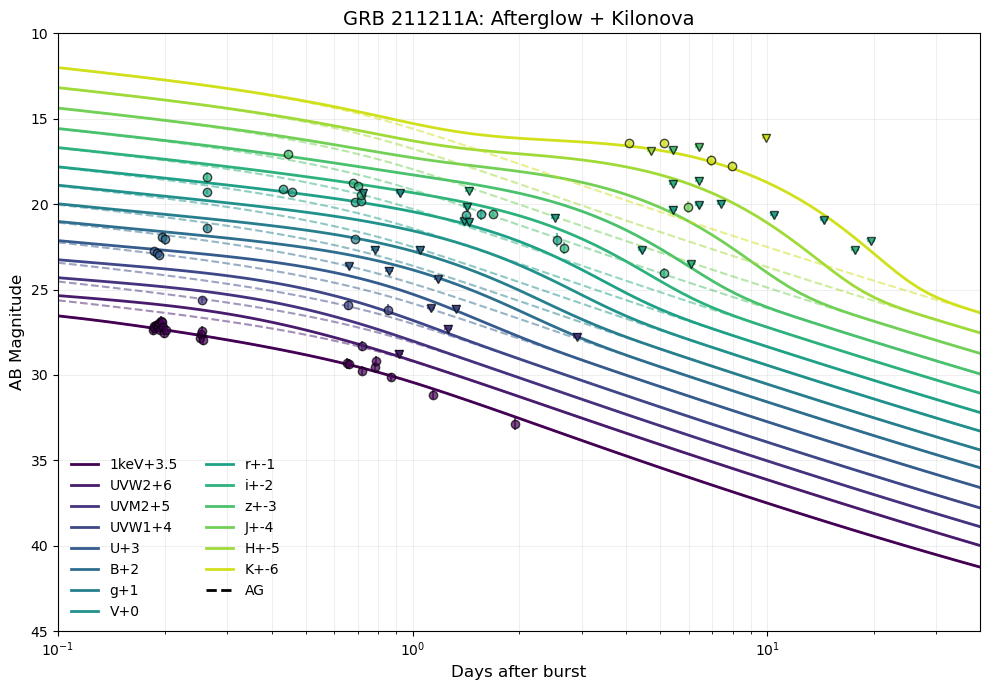

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const
import afterglowpy as grb
import os
import pandas as pd

# ==========================================
# physical constants
# ==========================================
L_SUN = const.L_sun.cgs.value
M_SUN = const.M_sun.cgs.value  # 1.989e33 g
C_CGS = const.c.cgs.value      # 3e10 cm/s
SIGMA_SB = const.sigma_sb.cgs.value  # 5.67e-5 erg/(cm²sK⁴)
H_CGS = const.h.cgs.value      # 6.626e-27 erg·s
K_B_CGS = const.k_B.cgs.value  # 1.38e-16 erg/K
DAY_S = 86400.0                # day to seconds

Z_REDSHIFT = 0.076             # redshift
DL_CM = 1.08e27                # luminosity distance

# ==========================================
# mag to flux
# ==========================================
def ABmag_to_Flux(mag):
    """AB mag to mJy"""
    return 10**((16.40 - mag) / 2.5)

def Flux_to_ABmag(flux_mJy):
    """mJy to AB mag"""
    flux_mJy = np.maximum(flux_mJy, 1e-30)
    return -2.5 * np.log10(flux_mJy) + 16.40


# ==========================================
# Engine-Fed Kilonova
# r-process + magnetor
# ==========================================
class EngineFedKilonova:
    def __init__(self, P0_ms=1.0, B13=1.9, Mej_solar=0.037, vej_c=0.24, kappa=0.73, fn=0.80):
        """
        :param P0_ms: period
        :param B13: surface magnetic field
        :param Mej_solar: total ejection mass
        :param vej_c: ejection velocity
        :param kappa: opacity
        :param fn: ratio
        """
        # magnetor
        self.P0 = P0_ms * 1e-3  # s
        self.B = B13 * 1e13     # G
        self.R_ns = 1e6         # radius
        self.eta = 1e-4        # efficiency (convert the wind energy into X-ray radiation)
        
        self.Mej = Mej_solar * M_SUN  # ejection mass（g)
        self.fn = fn                  # radiative mass ratio
        self.Mej_n = fn * self.Mej    # radiative ejection mass
        self.vej = vej_c * C_CGS      # ejection velocity（cm/s）
        self.kappa = kappa            # opacity（cm²/g）
        
        self.eps_radio = 1e-4    # transfer rate
        self.t_radio = 1 * DAY_S # r-process timescale（1 d）

    def _radio_heating_luminosity(self, t_sec):
        """r-process"""
        #return self.eps_radio * (self.Mej_n * C_CGS**2) / self.t_radio * np.exp(-t_sec / self.t_radio)
        t_day = t_sec / DAY_S
        eps_r = 0.5*2e10 * (t_day ** -1.3)  # erg/s/g
        return eps_r * self.Mej_n  # L_radio in erg/s
        #t_rest = t_sec / self.Gamma_ej  # rest-frame time
        #arg = (self.t0_ra - t_rest) / (self.t0_ra * self.sigma_ra)
        #f_ra = 0.5 - (1 / np.pi) * np.arctan(arg)
        #L_ra0 = 4e49 * (self.Mej / (0.01 * M_SUN))  # erg/s (scale with total Mej?)
        #return L_ra0 * f_ra  # erg/s (note: articles use Mej, but fn for neutron-rich)

    def _magnetar_injection_luminosity(self, t_sec):
        """magnetor injection"""
        # spin down luminosity
        Omega = 2 * np.pi / self.P0  # angular speed（rad/s)
        I0 = 1e45
        L_sd0 = (self.eta * self.B**2 * self.R_ns**6 * Omega**4) / (6 * C_CGS**3) # The luminosity for the magnetor is constant
        t_sd = (0.5 * I0 * Omega**2) / L_sd0  # spin down timescale
        L_sd = L_sd0 * (1 + t_sec / t_sd)**(-2) # time dependent
        
        # injection efficiency
        R = self.vej * t_sec  # radius for the ejection（cm）
        tau = 3*(self.kappa * self.Mej) / (4 * np.pi * R**2)  # optical depth = kappa*rho*R
        xi_t = 0.03 * np.exp(-1.0 / tau)  # correction
        efficiency = 0.5 * xi_t  # total ejection efficiency
        
        return efficiency * L_sd

    def bolometric_luminosity(self, t_sec):
        """Total luminosity from magnetor"""
        return self._radio_heating_luminosity(t_sec) + self._magnetar_injection_luminosity(t_sec)

    def flux_density(self, t_sec, nu_obs):
        """
        :param t_sec: time (s)
        :param nu_obs: frequency(Hz)
        :return: flux density (mJy)
        """
        # redshift correction
        nu_rest = nu_obs * (1 + Z_REDSHIFT)
        
        # Total luminosity
        L_bol = self.bolometric_luminosity(t_sec)
        R = self.vej * t_sec
        
        # effective temperature
        T_eff = (L_bol / (4 * np.pi * R**2 * SIGMA_SB))**0.25
        #T_eff = np.maximum(T_eff, 50) # cut
        
        # blackbody radiation
        exp_val = (H_CGS * nu_rest) / (K_B_CGS * T_eff)
        B_nu = (2 * H_CGS * nu_rest**3 / C_CGS**2) / (np.exp(exp_val) - 1)
        
        # convert to mJy
        F_nu = np.pi * (R / DL_CM)**2 * B_nu  # erg/(cm²sHz)
        return F_nu * 1e26  # convert to mJy（1 mJy = 1e-26 erg/(cm²sHz)）


# ==========================================
# GRB Afterglow
# ==========================================
def get_afterglow_flux(t_sec, nu_obs):
    """
    :param t_sec: time (s)
    :param nu_obs: frequency(Hz)
    :return: flux density (mJy)
    """
    # Afterglow paras
    theta_core = 10**-1.8
    Z = {
        'jetType':     grb.jet.Gaussian,     # Gaussian jet
        'specType':    0,                    # synchrotron
        'thetaObs':    10**-1.6,             # viewing angle（≈0.025 rad）
        'E0':          10**53.2,             # E_iso（erg）
        'thetaCore':   theta_core,           # core angle
        'thetaWing':   4 * theta_core,       # cutoff angle
        'n0':          10**-2.8,             # ambient density
        'p':           2.24,                 # spectral index
        'epsilon_e':   10**-2.3,             # epsilon_e
        'epsilon_B':   10**-2.0,             # epsilon_B
        'xi_N':        1.0,                  # ratio
        'd_L':         DL_CM,                # luminosity distance（cm）
        'z':           Z_REDSHIFT            # redshift
    }
    return grb.fluxDensity(t_sec, nu_obs, **Z) # mJy


# ==========================================
# main function
# ==========================================
def main():
    t_days = np.logspace(-1, 2, 100)
    t_sec = t_days * DAY_S
    
    unique_bands = ['1keV', 'UVW2', 'UVM2', 'UVW1', 'U', 'B', 'g', 'V', 'r', 'i', 'z', 'J', 'H', 'K']
    
    nu_dict = {
        '1keV': 2.418e17,
        'UVW2': 1.556e15,
        'UVM2': 1.335e15,
        'UVW1': 1.153e15,
        'U': 8.658e14,
        'B': 6.831e14,
        'g': 6.402e14,
        'V': 5.486e14,
        'r': 4.823e14,
        'i': 3.934e14,
        'z': 3.284e14,
        'J': 2.429e14,
        'H': 1.805e14,
        'K': 1.39e14
    }
    
    offset_dict = {
        '1keV': +3.5,
        'UVW1': +4,
        'UVM2': +5,
        'UVW2': +6,
        'U': +3,
        'B': +2,
        'g': +1,
        'V': 0,
        'r': -1,
        'i': -2,
        'z': -3,
        'J': -4,
        'H': -5,
        'K': -6
    }
    
    band_map = {
        '1keV': '1keV',
        'UVW2': 'UVW2',
        'UVM2': 'UVM2',
        'UVW1': 'UVW1',
        'U': 'U',
        'B': 'B',
        "g'": 'g',
        'g': 'g',
        'V': 'V',
        'r': 'r',
        'Rc': 'r',
        'R': 'r',
        "r'": 'r',
        'i': 'i',
        'Ic': 'i',
        'I': 'i',
        'z': 'z',
        'J': 'J',
        'H': 'H',
        'K': 'K'
    }

    # parameters for the kilonova
    kn_params = {
        'P0_ms':     1.0,    # period（ms）
        'B13':       1.9,    # magnetic field（10^13 G）
        'Mej_solar': 0.037,  # ejection mass
        'vej_c':     0.24,   # ejection speed
        'kappa':     0.73,   # opacity
        'fn':        0.80    # radiative ratio
    }
    KN_model = EngineFedKilonova(**kn_params)
    
    # flux in all bands
    # F_KN_r = KN_model.flux_density(t_sec, nu_dict['r-band'])
    # F_KN_K = KN_model.flux_density(t_sec, nu_dict['K-band'])

    # --- afterglow ---
    # F_AG_r = get_afterglow_flux(t_sec, nu_dict['r-band'])
    # F_AG_K = get_afterglow_flux(t_sec, nu_dict['K-band'])

    # --- Total flux ---
    # F_total_r = F_AG_r + F_KN_r
    # F_total_K = F_AG_K + F_KN_K

    df = pd.read_csv('GRB211211A_MW_DATA.txt', sep='\t', skipinitialspace=True)
    
    plt.figure(figsize=(10, 7))
    
    num_bands = len(unique_bands)
    colors = [plt.cm.viridis(i / num_bands) for i in range(num_bands)]
    color_dict = dict(zip(unique_bands, colors))
    
    for band in unique_bands:
        nu = nu_dict[band]
        F_KN = KN_model.flux_density(t_sec, nu)
        F_AG = get_afterglow_flux(t_sec, nu)
        F_total = F_AG + F_KN
        offset = offset_dict[band]
        color = color_dict[band]
        plt.plot(t_days, Flux_to_ABmag(F_AG) + offset, '--', color=color, alpha=0.5)
        plt.plot(t_days, Flux_to_ABmag(F_total) + offset, '-', color=color, linewidth=2, label=f'{band}+{offset}')
    
    plt.plot(t_days, np.zeros(len(t_days)), '--', color='k', linewidth=2, label='AG')
    plt.plot(t_days, np.zeros(len(t_days)), '-', color='k', linewidth=2, label='AG + engine-fed kilonova')
    
    for index, row in df.iterrows():
        t = row['t/day']
        band = row['band']
        plot_band = band_map.get(band, band)
        if plot_band not in unique_bands:
            continue
        offset = offset_dict[plot_band]
        fd = row['fd/mjy']
        fd_min = row['fd-/mjy']
        fd_plus = row['fd+/mjy']
        mag = Flux_to_ABmag(fd) + offset
        err_flux = (fd_min + fd_plus) / 2
        err_mag = 1.0857 * (err_flux / fd) if fd > 0 else 0.2
        uplim = row['uplim'] # boolean
        color = color_dict[plot_band]
        if t > 0.1:
            if uplim:
                plt.errorbar(t, mag, yerr=err_mag, fmt='v', color=color, uplims=True, markeredgecolor='black', alpha=0.7, markersize=6, capsize=3, capthick=1.5)
            else:
                plt.errorbar(t, mag, yerr=err_mag, fmt='o', color=color, markeredgecolor='black', alpha=0.7, markersize=6)

    plt.gca().invert_yaxis() 
    plt.xscale('log')         
    plt.xlabel('Days after burst', fontsize=12)
    plt.ylabel('AB Magnitude', fontsize=12)
    plt.title('GRB 211211A: Afterglow + Kilonova', fontsize=14)
    plt.legend(fontsize=10, ncol = 2)
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(1e-1, 10**1.6)
    plt.ylim(45, 10)
    plt.tight_layout()
    plt.savefig('GRB211211A_AG_KN_Fit_NoExtinction.png', dpi=300)
    plt.savefig('GRB211211A_AG_KN_Fit_NoExtinction.png', dpi=300, format = 'pdf')
    plt.legend(frameon = False, ncol = 2)
    plt.show()
    
    '''
    plt.figure(figsize=(10, 7))
    color_dict = {'r-band': 'red', 'K-band': 'blue'}
    
    plt.plot(t_days, Flux_to_ABmag(F_AG_r), '--', color='red', alpha=0.5, label='Afterglow (r-band)')
    plt.plot(t_days, Flux_to_ABmag(F_total_r), '-', color='red', linewidth=2, label='Afterglow+Kilonova (r-band)')
    plt.plot(t_days, Flux_to_ABmag(F_AG_K), '--', color='blue', alpha=0.5, label='Afterglow (K-band)')
    plt.plot(t_days, Flux_to_ABmag(F_total_K), '-', color='blue', linewidth=2, label='Afterglow+Kilonova (K-band)')
    
    for index, row in df.iterrows():
        t = row['t/day']
        band = row['band']
        if band not in ['r', 'Rc', 'K']:
            continue
        plot_band = 'r-band' if 'r' in band else 'K-band'
        fd = row['fd/mjy']
        fd_min = row['fd-/mjy']
        fd_plus = row['fd+/mjy']
        mag = Flux_to_ABmag(fd)
        err_flux = (fd_min + fd_plus) / 2
        err_mag = 1.0857 * (err_flux / fd)
        uplim = row['uplim']
        if t > 0.1:
            if uplim:
                plt.errorbar(t, mag, yerr=err_mag, fmt='v', color=color_dict[plot_band], uplims=True, markeredgecolor='black', alpha=0.7, markersize=6)
            else:
                plt.errorbar(t, mag, yerr=err_mag, fmt='o', color=color_dict[plot_band], markeredgecolor='black', alpha=0.7, markersize=6)

    plt.gca().invert_yaxis() 
    plt.xscale('log')         
    plt.xlabel('Time since burst (days)', fontsize=12)
    plt.ylabel('AB Magnitude', fontsize=12)
    plt.title('GRB 211211A: Afterglow + Engine-Fed Kilonova Fit', fontsize=14)
    plt.legend(fontsize=10, loc='upper left')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.xlim(1e-1, 10**1.7)
    plt.tight_layout()
    plt.savefig('GRB211211A_AG_KN_Fit_NoExtinction.png', dpi=300)
    plt.show()'''


if __name__ == "__main__":
    main()